### *Locations Datasets*: Exploring the dataset

In [4]:
# import pandas
import pandas as pd
# import numpy 
import numpy as np
# import matplotlib
import matplotlib.pyplot as plt
# import seaborn
import seaborn as sns 

In [5]:
# import data
data = pd.read_excel('C:\\Users\\ratha\\OneDrive\\Placement\\end-to-end-projects\\jcci-route-optimizer\\data\\jcci_location_data_latti_longi.xlsx')
# Explore Data
data.head()

,Node_ID,Retailer_Name,Latitude,Longitude,Esti_Demand_Per_Day_kg
0,1,Sethi Corporate Cafeteria,28.719278,77.053170,900
1,2,Bansal Agency,28.757394,77.151107,580
2,3,Malik Mart,28.726024,77.213603,560
3,4,Singh Store,28.795012,77.142575,400
4,5,Malik Provision Store,28.782713,77.035929,760


In [6]:
# Change the columns names lower case. 
data.columns = data.columns.str.lower()

# top rows
data.head()

,node_id,retailer_name,latitude,longitude,esti_demand_per_day_kg
0,1,Sethi Corporate Cafeteria,28.719278,77.053170,900
1,2,Bansal Agency,28.757394,77.151107,580
2,3,Malik Mart,28.726024,77.213603,560
3,4,Singh Store,28.795012,77.142575,400
4,5,Malik Provision Store,28.782713,77.035929,760


In [7]:
# Explore Data 
print('Number of Rows:',data.shape[0])
print('Number of Columns:',data.shape[1])

# Describe Statistics for Numerical Columns
data[['node_id','esti_demand_per_day_kg']].describe()

Number of Rows: 1032
Number of Columns: 5


,node_id,esti_demand_per_day_kg
count,1032.000000,1032.000000
mean,516.500000,521.874031
std,298.057042,202.805607
min,1.000000,160.000000
25%,258.750000,360.000000
50%,516.500000,520.000000
75%,774.250000,680.000000
max,1032.000000,980.000000


In [8]:
# Check for the duplicates 'retailer_name'  of the retailer names
d1 = data['retailer_name'].value_counts()[data['retailer_name'].value_counts() > 1]
print(d1)
print(f'Out of 1032 Retailers {d1.shape[0]} have duplicate Names')

# Check for the duplicate
d2 = data[['latitude','longitude']].value_counts()[data[['latitude','longitude']].value_counts() > 1].shape[0]
print('Duplicates Retailer_Name, Not have exact Locations', d2)

retailer_name
Kapoor Agency               6
Arora Super Store           6
Kumar Daily Needs           5
Arora Family Store          5
Mehta Departmental Store    5
                           ..
Verma Family Store          2
Pandey Kirana Bhandar       2
Mehta Retail Hub            2
Kumar Pharmacy              2
Mehta Enterprise            2
Name: count, Length: 267, dtype: int64
Out of 1032 Retailers 267 have duplicate Names
Duplicates Retailer_Name, Not have exact Locations 0


<Axes: ylabel='Density'>

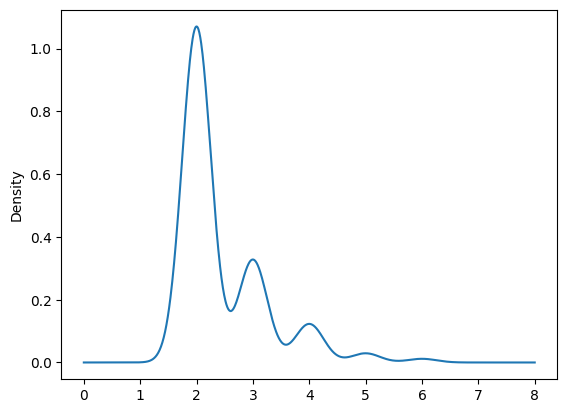

In [9]:
# Plot the histogram for the duplicates retailer name.
data['retailer_name'].value_counts()[data['retailer_name'].value_counts() > 1].plot(kind='kde')

### *Vehicle Distance Dataset*

In [10]:
# import dataset
dist = pd.read_excel('C:\\Users\\ratha\\OneDrive\\Placement\\end-to-end-projects\\jcci-route-optimizer\\data\\vehicle_dist_data_from_mar_to_apr.xlsx')

# Check the dataset
dist.head()

,Vehicle_ID,Day_1,Day_2,Day_3,Day_4,Day_5,Day_6,Day_7,Day_8,Day_9,...,Day_51,Day_52,Day_53,Day_54,Day_55,Day_56,Day_57,Day_58,Day_59,Day_60
0,0,88.9,83.3,72.3,0.0,100.7,71.4,70.3,108.3,91.1,...,100.7,110.0,77.0,64.5,54.0,60.8,121.6,109.9,104.4,95.0
1,1,84.2,172.2,79.9,97.9,79.9,88.4,51.9,83.2,83.2,...,152.0,178.0,155.8,181.3,121.3,101.6,104.6,151.3,164.2,135.3
2,2,58.6,155.6,184.6,72.8,161.3,80.8,84.8,83.1,169.8,...,97.6,101.4,68.5,137.3,96.0,65.1,154.3,110.7,96.5,126.1
3,3,120.7,79.6,124.2,98.0,169.4,114.3,123.9,112.2,69.4,...,168.1,85.3,111.6,121.9,100.9,85.4,80.1,105.9,115.5,127.9
4,4,157.4,166.3,156.6,138.8,155.2,102.8,87.7,130.3,141.6,...,171.9,163.4,173.0,193.8,0.0,0.0,161.5,158.6,178.9,191.6


In [11]:
# Change the columns names into the lowercase
dist.columns = dist.columns.str.lower()

# Data rows overview
dist.head()

,vehicle_id,day_1,day_2,day_3,day_4,day_5,day_6,day_7,day_8,day_9,...,day_51,day_52,day_53,day_54,day_55,day_56,day_57,day_58,day_59,day_60
0,0,88.9,83.3,72.3,0.0,100.7,71.4,70.3,108.3,91.1,...,100.7,110.0,77.0,64.5,54.0,60.8,121.6,109.9,104.4,95.0
1,1,84.2,172.2,79.9,97.9,79.9,88.4,51.9,83.2,83.2,...,152.0,178.0,155.8,181.3,121.3,101.6,104.6,151.3,164.2,135.3
2,2,58.6,155.6,184.6,72.8,161.3,80.8,84.8,83.1,169.8,...,97.6,101.4,68.5,137.3,96.0,65.1,154.3,110.7,96.5,126.1
3,3,120.7,79.6,124.2,98.0,169.4,114.3,123.9,112.2,69.4,...,168.1,85.3,111.6,121.9,100.9,85.4,80.1,105.9,115.5,127.9
4,4,157.4,166.3,156.6,138.8,155.2,102.8,87.7,130.3,141.6,...,171.9,163.4,173.0,193.8,0.0,0.0,161.5,158.6,178.9,191.6


In [12]:
# Reset Index 
dist.set_index('vehicle_id', inplace=True)

# Summarize Data Statistics
print(dist.describe())

            day_1       day_2       day_3       day_4       day_5       day_6  \
count   87.000000   87.000000   87.000000   87.000000   87.000000   87.000000   
mean   128.968966  127.883908  128.545977  128.781609  129.556322   90.949425   
std     39.420631   41.966376   46.773812   46.112235   40.838214   38.944701   
min     16.600000    0.000000    0.000000    0.000000   61.300000    0.000000   
25%     97.150000   97.850000   92.450000   89.400000  102.200000   64.000000   
50%    137.200000  130.400000  134.100000  139.900000  127.100000  100.900000   
75%    157.400000  157.950000  164.600000  164.700000  163.600000  111.800000   
max    207.600000  199.500000  211.800000  207.900000  247.700000  211.500000   

            day_7       day_8       day_9      day_10  ...      day_51  \
count   87.000000   87.000000   87.000000   87.000000  ...   87.000000   
mean    97.848276  127.395402  124.589655  122.757471  ...  130.939080   
std     38.328297   40.148738   54.829024   38.7

vehicle_id
0     4786.3
1     5402.0
2     6746.7
3     6551.7
4     8911.6
       ...  
82    9185.0
83    8497.5
84    4616.4
85    9185.0
86    6377.8
Length: 87, dtype: float64


Text(0.5, 1.0, 'Distance Covered by Each Vehicle')

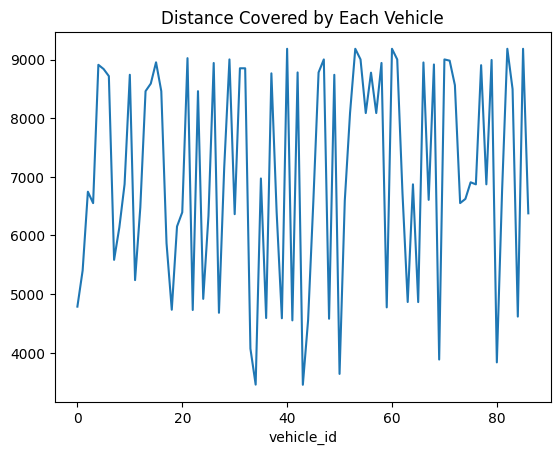

In [ ]:
# Info of the data
dist['day_1'].info

# Total distance covered by each vehicle in last 60 days?
print(dist.sum(axis=1))

# Plot Graph
dist.sum(axis=1).plot(kind='line')
plt.title('Distance Covered by Each Vehicle')

vehicle_id
0      79.771667
1      90.033333
2     112.445000
3     109.195000
4     148.526667
         ...    
82    153.083333
83    141.625000
84     76.940000
85    153.083333
86    106.296667
Length: 87, dtype: float64


Text(0.5, 1.0, 'Average Distance Covered by Each Vehicle')

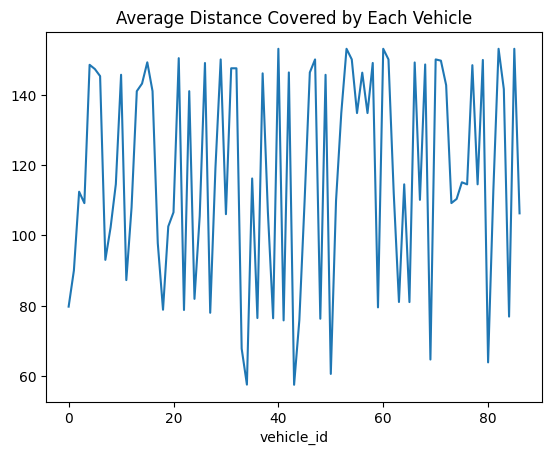

In [31]:
# Average Distance covered by each vehicle in last 60 days?
# Total Distance
print(dist.mean(axis=1))

# Plot Graph
dist.mean(axis=1).plot(kind='line')
plt.title('Average Distance Covered by Each Vehicle')

In [40]:
# Distance travelled by fleet of vehicles each day.
pd.DataFrame(dist.sum(axis=0)).describe()

,0
count,60.000000
mean,10213.485000
std,1478.827386
min,6356.200000
25%,8646.450000
50%,10863.950000
75%,11186.450000
max,11857.500000


In [ ]:
# Check for the np.nan values. 
dist.isnull().sum()[dist.isnull().sum() > 0].shape[0]

0